# Augmentations-2: Augmentations

In [1]:
import os
import sys
import time
from pathlib import Path

root = Path.cwd()
print(root)
if root.name == "ipynb":
    root = root.parent
    os.chdir(root)
print(root)

_ipynb = Path.cwd() / "ipynb"
if str(_ipynb) not in sys.path:
    sys.path.insert(0, str(_ipynb))

import zarr
import tifffile
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy.ndimage import rotate

from view_augments.base_data import (
    ORIGINAL_DIR,
    ORIGINAL_MIP_DIR,
    PCT_LOW,
    PCT_HIGH,
    GAMMA,
    enhance_display,
    fisbe_rgb_mip,
    per_channel_stats,
    per_channel_histogram,
)
from view_augments.augmentations_applied import (
    FISBE_DIR,
    fisbe_gt_instance_mip,
    plot_augmentation_samples,
)


/scratch/wmz2007/neuroinfo_fruitfly/ipynb
/scratch/wmz2007/neuroinfo_fruitfly


In [ ]:
SAMPLE = "JRC_SS04989-20160318_24_A2"
SPLIT = "test"
AUG_NAME = "biapy-channel-rot"
RNG_SEED = 22

## TIFF CHECK

### No Augmentations

In [ ]:
AUG_NAME = "biapy-no-aug"
no_aug_FS = (3, 3)
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    True, fisbe_rgb_mip, RNG_SEED,
    sample_selection=1,
    subplots=(1, 1),
    fig_size=no_aug_FS
)
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    False, fisbe_gt_instance_mip, RNG_SEED,
    sample_selection=1,
    subplots=(1, 1),
    fig_size=no_aug_FS
)


### Channel-Rot

In [ ]:
AUG_NAME = "biapy-channel-rot"
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    True, fisbe_rgb_mip, RNG_SEED
)
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    False, fisbe_gt_instance_mip, RNG_SEED
)


### Channel Scale

In [5]:
os.listdir("fisbe/biapy-no-aug/test/label")

['JRC_SS04989-20160318_24_A2.tif',
 'R14A02-20180905_65_A6.tif',
 'R54A09-20181019_64_H1.tif',
 'VT011145-20171222_63_I1.tif',
 'VT027175-20171031_62_H3.tif',
 'VT027175-20171031_62_H4.tif',
 'VT050157-20171110_61_C1.tif']

In [6]:
SAMPLE="VT011145-20171222_63_I1"
# RNG_SEED=

fisbe/biapy-channel-scale/test/raw
VT011145-20171222_63_I1*
Total augmentations for sample found: 8
Selecting (4) samples


  0%|          | 0/4 [00:00<?, ?it/s]

Shape: (417, 3, 685, 685) dtype: uint16 max: 5828, min: 0 Image Shape: (417, 3, 685, 685)
Shape: (417, 3, 685, 685) dtype: uint16 max: 3459, min: 0 Image Shape: (417, 3, 685, 685)


 25%|██▌       | 1/4 [00:01<00:04,  1.62s/it]

Shape: (417, 3, 685, 685) dtype: uint16 max: 1368, min: 0 Image Shape: (417, 3, 685, 685)
Shape: (417, 3, 685, 685) dtype: uint16 max: 5836, min: 0 Image Shape: (417, 3, 685, 685)


100%|██████████| 4/4 [00:03<00:00,  1.24it/s]


Transformed image shape: (685, 685, 3)


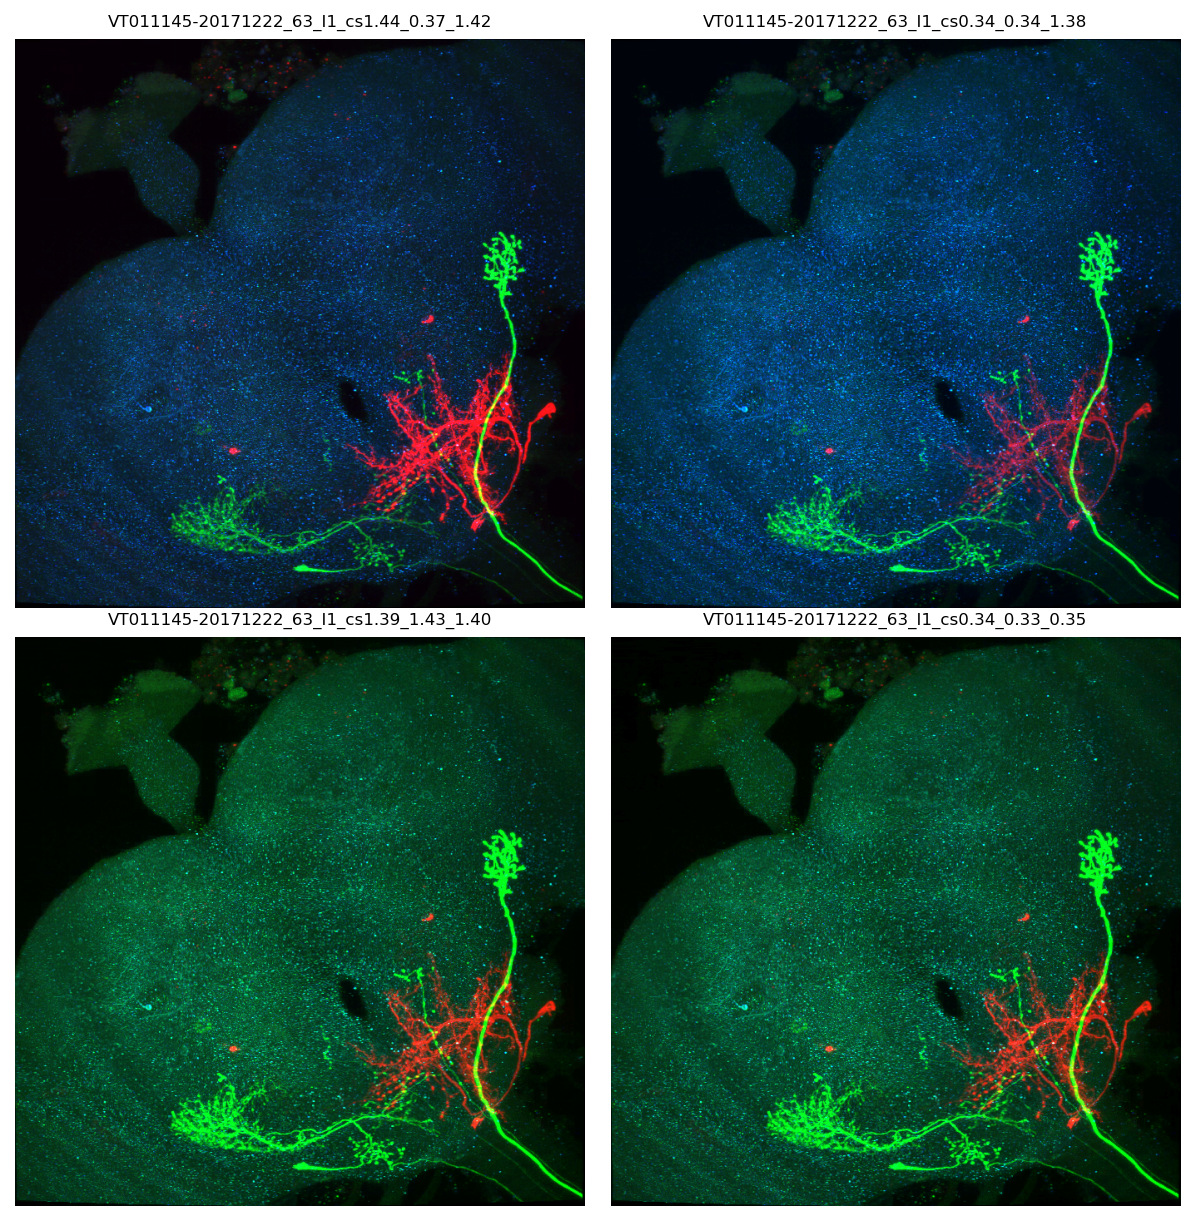

In [7]:
AUG_NAME = "biapy-channel-scale"
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    True, fisbe_rgb_mip, RNG_SEED,
)


### Instance Scale

In [ ]:
AUG_NAME = "biapy-instance-scale"
SAMPLE = "R14A02-20180905_65_A6"
SPLIT = "test"
RNG_SEED = 22
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    True, fisbe_rgb_mip, RNG_SEED
)


## ZARR CHECK

### Channel Scale

In [2]:
os.listdir("fisbe/biapy-channel-scale-zarr/test/label")

['JRC_SS04989-20160318_24_A2_cs0.27_0.33_1.45.zarr',
 'JRC_SS04989-20160318_24_A2_cs0.36_1.44_1.43.zarr',
 'JRC_SS04989-20160318_24_A2_cs1.39_1.47_0.34.zarr',
 'JRC_SS04989-20160318_24_A2_cs1.41_0.32_0.32.zarr',
 'R14A02-20180905_65_A6_cs0.29_0.26_1.45.zarr',
 'R14A02-20180905_65_A6_cs0.29_1.46_0.30.zarr',
 'R14A02-20180905_65_A6_cs0.36_1.48_1.46.zarr',
 'R14A02-20180905_65_A6_cs1.47_0.33_1.43.zarr',
 'R54A09-20181019_64_H1_cs0.33_0.30_0.34.zarr',
 'R54A09-20181019_64_H1_cs0.35_1.41_0.28.zarr',
 'R54A09-20181019_64_H1_cs1.44_0.27_1.41.zarr',
 'R54A09-20181019_64_H1_cs1.49_0.27_0.37.zarr',
 'VT011145-20171222_63_I1_cs0.31_1.38_1.48.zarr',
 'VT011145-20171222_63_I1_cs1.44_0.32_0.26.zarr',
 'VT011145-20171222_63_I1_cs1.44_0.36_1.38.zarr',
 'VT011145-20171222_63_I1_cs1.47_1.45_1.49.zarr',
 'VT027175-20171031_62_H3_cs0.29_0.34_1.48.zarr',
 'VT027175-20171031_62_H3_cs1.41_1.46_1.40.zarr',
 'VT027175-20171031_62_H3_cs1.42_0.37_1.43.zarr',
 'VT027175-20171031_62_H3_cs1.49_0.25_0.28.zarr',
 'VT

fisbe/biapy-debug-zarr/test/raw
JRC_SS04989-20160318_24_A2*
Total augmentations for sample found: 1
Selecting (4) samples


  0%|          | 0/4 [00:00<?, ?it/s]

Shape: (390, 680, 680, 3) dtype: uint16 max: 4095, min: 0 Image Shape: (390, 680, 680, 3)
Shape: (390, 680, 680, 3) dtype: uint16 max: 4095, min: 0 Image Shape: (390, 680, 680, 3)


 50%|█████     | 2/4 [00:03<00:02,  1.35s/it]

Shape: (390, 680, 680, 3)Shape: (390, 680, 680, 3) dtype: uint16 max: 4095, min: 0 Image Shape: (390, 680, 680, 3)
 dtype: uint16 max: 4095, min: 0 Image Shape: (390, 680, 680, 3)


100%|██████████| 4/4 [00:06<00:00,  1.52s/it]


Transformed image shape: (680, 680, 3)


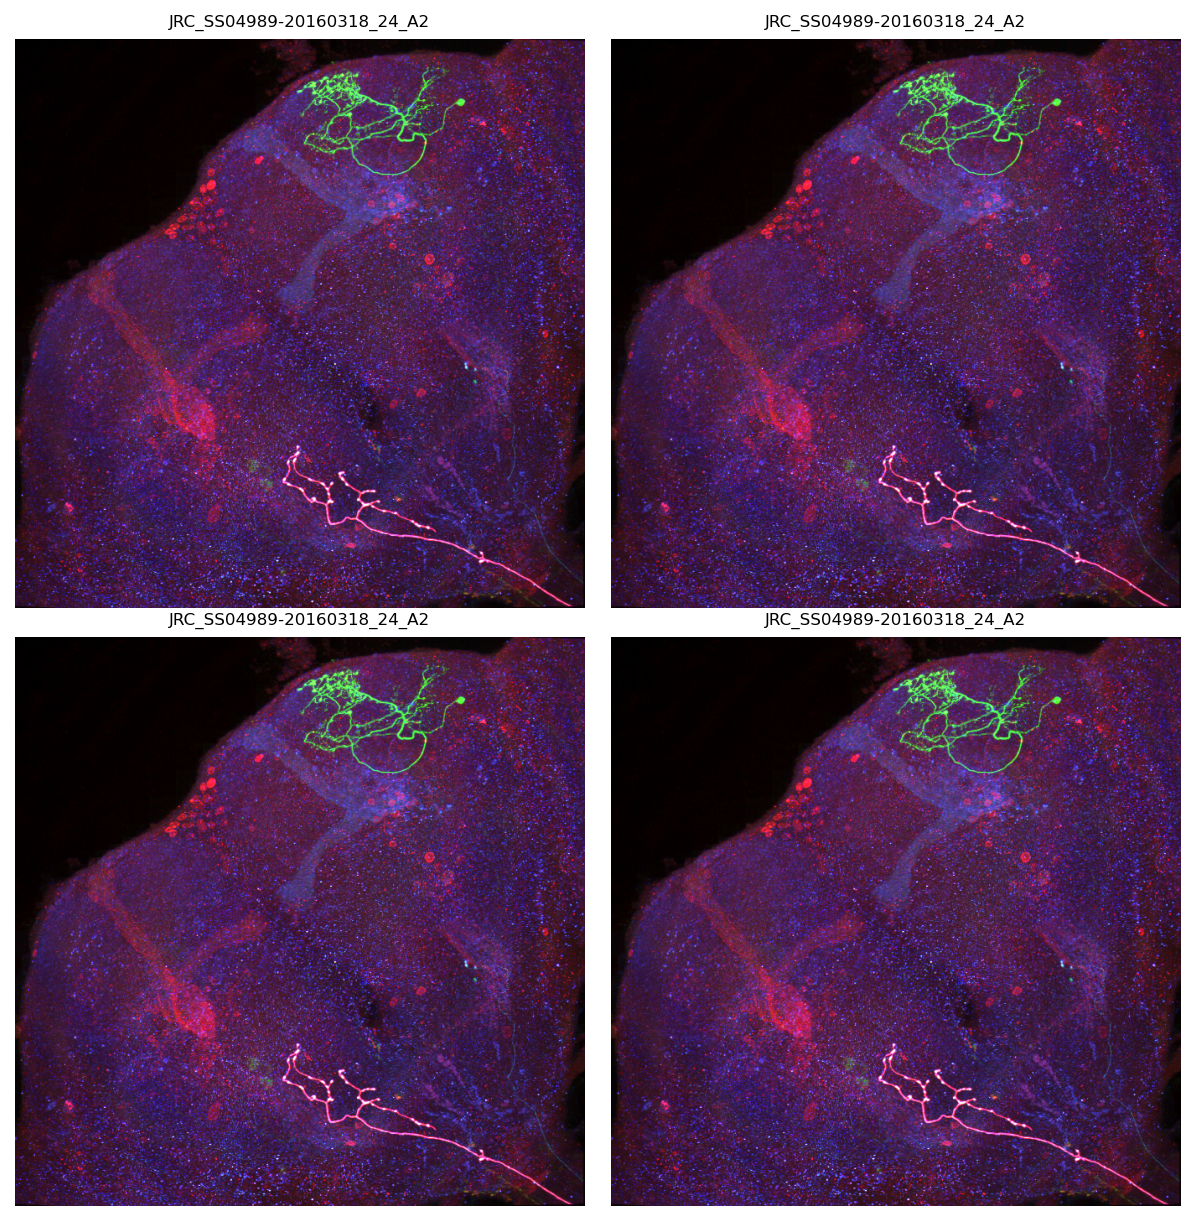

In [3]:
AUG_NAME = "biapy-debug-zarr"
SAMPLE="JRC_SS04989-20160318_24_A2"
SPLIT = "test"
RNG_SEED = 22
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    True, fisbe_rgb_mip, RNG_SEED,
)


### Instance Scale

fisbe/biapy-instance-scale-zarr/test/raw
R14A02-20180905_65_A6*
Total augmentations for sample found: 4
Selecting (4) samples


  0%|          | 0/4 [00:00<?, ?it/s]

Shape: (385, 685, 686, 3) dtype: uint16 max: 6039, min: 0 Image Shape: (385, 685, 686, 3)
Shape: (385, 685, 686, 3) dtype: uint16 max: 5937, min: 0 Image Shape: (385, 685, 686, 3)


 50%|█████     | 2/4 [00:02<00:02,  1.13s/it]

Shape: (385, 685, 686, 3) dtype: uint16 max: 4095, min: 0 Image Shape: (385, 685, 686, 3)
Shape: (385, 685, 686, 3) dtype: uint16 max: 7443, min: 0 Image Shape: (385, 685, 686, 3)


100%|██████████| 4/4 [00:05<00:00,  1.28s/it]


Transformed image shape: (685, 686, 3)


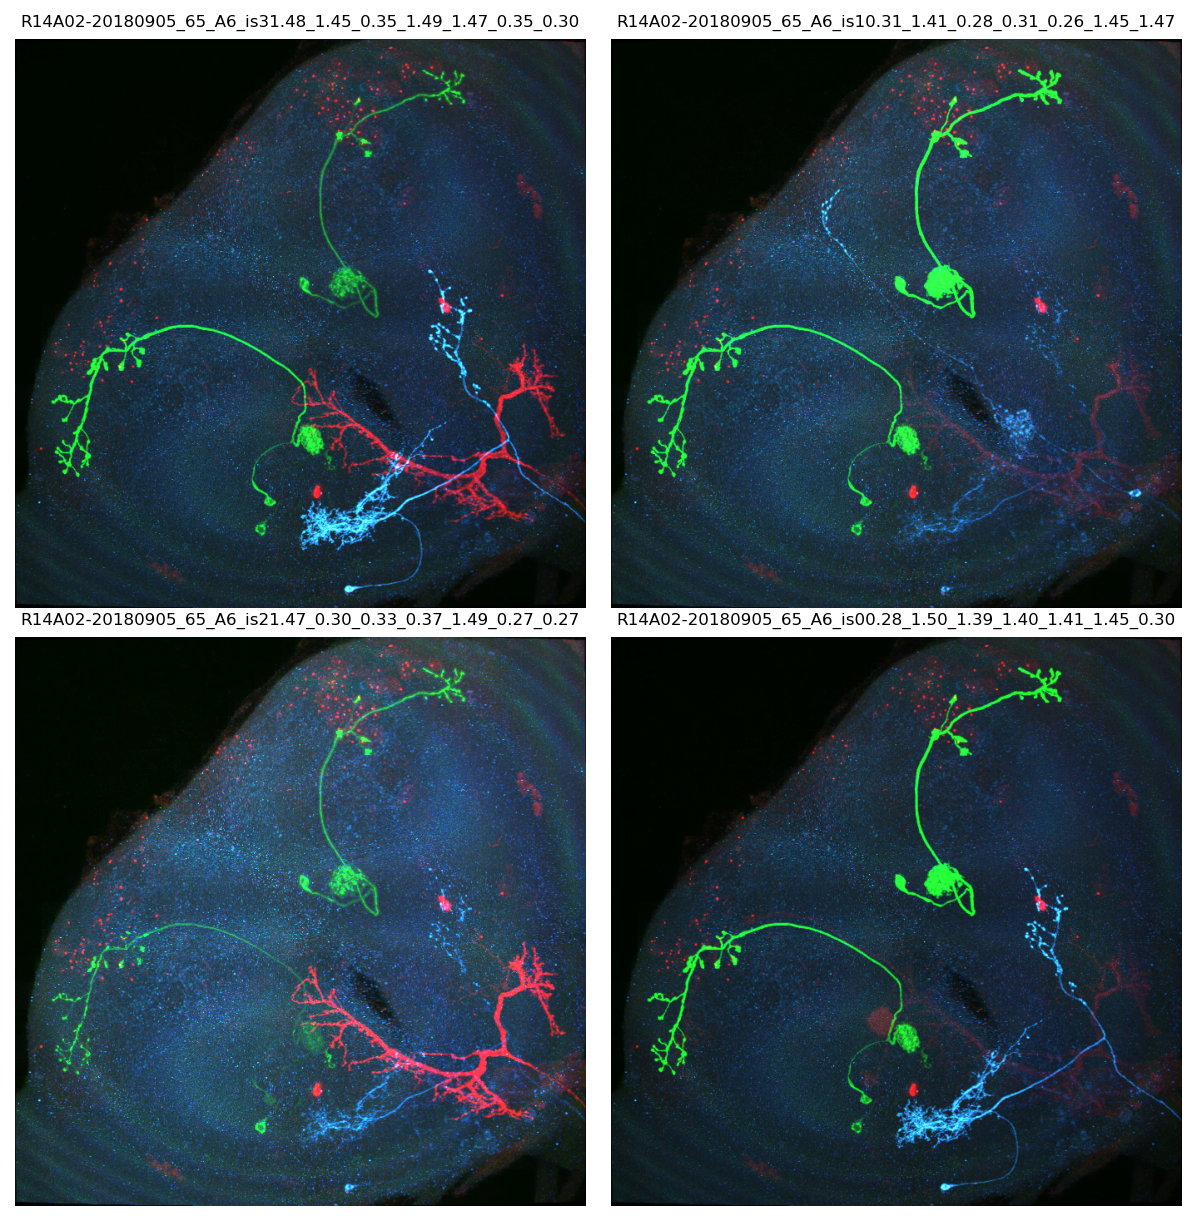

In [4]:
AUG_NAME = "biapy-instance-scale-zarr"
SAMPLE = "R14A02-20180905_65_A6"
SPLIT = "test"
RNG_SEED = 22
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    True, fisbe_rgb_mip, RNG_SEED
)
